# DS: Projeto Final – Telecomunicação 

# Condições da Tarefa Principal

A operadora de comunicações Interconnect gostaria de ser capaz de predizer a rotatividade de seus clientes. Se for descoberto que um usuário está planejando trocar de operadora, a empresa oferecerá-lhe códigos promocionais e opções de plano especiais. A equipe de marketing da Interconnect coletou alguns dados pessoais da sua clientela, incluindo a informação sobre seus planos e contratos.

### Serviços da Interconnect

A Interconnect fornece principalmente dois tipos de serviços:

1. Telefonia fixa. O telefone pode ser conectado a várias linhas ao mesmo tempo.
2. Internet. A rede pode ser estabelecida através de uma linha telefônica (DSL, *digital subscriber line - linha digital de assinante*) ou através de um cabo de fibra óptica.

Alguns outros serviços fornecidos pela empresa incluem:

- Segurança na Internet: software de antivírus (*DeviceProtection* - proteção de dispositivos) e um bloqueador de sites maliciosos (*OnlineSecurity* - segurança online).
- Uma linha dedicada de suporte técnico (*TechSupport*).
- Armazenamento de arquivos na nuvem e backup de dados (*OnlineBackup*).
- Streaming de TV (*StreamingTV*) e um diretório de filmes (*StreamingMovies*).

Os clientes podem escolher entre fazer um pagamento mensal e assinar um contrato de 1 ou 2 anos. Eles podem usar vários métodos de pagamento e receber uma fatura eletrônica após a transação.

### Descrição dos Dados

Os dados consistem de arquivos obtidos de fontes diferentes:

- `contract.csv` — informação contratual;
- `personal.csv` — dados pessoais do cliente;
- `internet.csv` — informação sobre serviços de Internet;
- `phone.csv` — informação sobre serviços de telefonia.

Em cada arquivo, a coluna `customerID` contém um código unívoco atribuído a cada cliente. A informação contratual é válida a partir de 1 de fevereiro de 2020.

# Etapas do Projeto

- Elaborar um plano de trabalho.
- Investigar a tarefa.
- Desenvolver um modelo.
- Preparar o relatório.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import sklearn.linear_model
import sklearn.metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
import sklearn.preprocessing 
from sklearn.preprocessing import StandardScaler
import math
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
df_contrats = pd.read_csv('final_provider/final_provider/contract.csv')
df_internets = pd.read_csv('final_provider/final_provider/internet.csv')
df_personals = pd.read_csv('final_provider/final_provider/personal.csv')
df_phones = pd.read_csv('final_provider/final_provider/phone.csv')

In [3]:
df_contrats.info()
df_contrats.head()
df_contrats.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [4]:
df_internets.info()
df_internets.head()
df_internets.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,3186-AJIEK,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785


In [5]:
df_personals.info()
df_personals.head()
df_personals.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


,SeniorCitizen
count,7043.000000
mean,0.162147
std,0.368612
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [6]:
df_phones.info()
df_phones.head()
df_phones.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


,customerID,MultipleLines
count,6361,6361
unique,6361,2
top,3186-AJIEK,No
freq,1,3390


In [7]:
#Dimensão dos dados
print(df_contrats.shape)
print(df_internets.shape)
print(df_personals.shape)
print(df_phones.shape)

(7043, 8)
(5517, 8)
(7043, 5)
(6361, 2)


In [8]:
#Verificar valores nulos
print(df_contrats.isnull().sum())
print(df_internets.isnull().sum())
print(df_personals.isnull().sum())
print(df_phones.isnull().sum())

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64
customerID       0
MultipleLines    0
dtype: int64


In [9]:
#Elaborar um plano de trabalho
#Análise Exploratória (EDA)
print(df_contrats.describe())
print(df_internets['InternetService'].value_counts())
print(df_personals['gender'].value_counts())
print(df_phones['MultipleLines'].value_counts())

       MonthlyCharges
count     7043.000000
mean        64.761692
std         30.090047
min         18.250000
25%         35.500000
50%         70.350000
75%         89.850000
max        118.750000
InternetService
Fiber optic    3096
DSL            2421
Name: count, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
MultipleLines
No     3390
Yes    2971
Name: count, dtype: int64


In [10]:
#Investigar a tarefa
df_merged = df_personals \
    .merge(df_contrats, on='customerID') \
    .merge(df_internets, on='customerID') \
    .merge(df_phones, on='customerID')

In [11]:
#Converter colunas numéricas, se necessário
df_merged['TotalCharges'] = pd.to_numeric(df_merged['TotalCharges'], errors='coerce')

In [12]:
#Resumo estatístico geral
print(df_merged.describe(include='all'))

#Tipos de dados
print(df_merged.dtypes)

#Verificar duplicatas
print(df_merged.duplicated().sum())

        customerID gender  SeniorCitizen Partner Dependents   BeginDate  \
count         4835   4835    4835.000000    4835       4835        4835   
unique        4835      2            NaN       2          2          77   
top     3186-AJIEK   Male            NaN      No         No  2014-02-01   
freq             1   2425            NaN    2482       3574         269   
mean           NaN    NaN       0.203930     NaN        NaN         NaN   
std            NaN    NaN       0.402959     NaN        NaN         NaN   
min            NaN    NaN       0.000000     NaN        NaN         NaN   
25%            NaN    NaN       0.000000     NaN        NaN         NaN   
50%            NaN    NaN       0.000000     NaN        NaN         NaN   
75%            NaN    NaN       0.000000     NaN        NaN         NaN   
max            NaN    NaN       1.000000     NaN        NaN         NaN   

       EndDate            Type PaperlessBilling     PaymentMethod  \
count     4835            4835

In [13]:
#Distribuição por gênero
print(df_merged['gender'].value_counts(normalize=True))

#Proporção de idosos
print(df_merged['SeniorCitizen'].value_counts(normalize=True))

#Clientes com dependentes
print(df_merged['Dependents'].value_counts(normalize=True))

gender
Male      0.501551
Female    0.498449
Name: proportion, dtype: float64
SeniorCitizen
0    0.79607
1    0.20393
Name: proportion, dtype: float64
Dependents
No     0.739193
Yes    0.260807
Name: proportion, dtype: float64


In [14]:
#Tipos de serviço de internet
print(df_merged['InternetService'].value_counts())

#Segurança online
print(df_merged['OnlineSecurity'].value_counts())

#Linhas telefônicas múltiplas
print(df_merged['MultipleLines'].value_counts())

InternetService
Fiber optic    3096
DSL            1739
Name: count, dtype: int64
OnlineSecurity
No     3099
Yes    1736
Name: count, dtype: int64
MultipleLines
Yes    2629
No     2206
Name: count, dtype: int64


In [15]:
#Métodos de pagamento
print(df_merged['PaymentMethod'].value_counts())

#Clientes com e sem cobrança automática
print(df_merged['PaperlessBilling'].value_counts())

#Média e distribuição dos gastos mensais
print(df_merged['MonthlyCharges'].describe())

#Total gasto por cliente
print(df_merged['TotalCharges'].describe())

PaymentMethod
Electronic check             2017
Bank transfer (automatic)    1069
Credit card (automatic)      1037
Mailed check                  712
Name: count, dtype: int64
PaperlessBilling
Yes    3338
No     1497
Name: count, dtype: int64
count    4835.000000
mean       81.755171
std        18.303085
min        42.900000
25%        69.775000
50%        82.500000
75%        95.700000
max       118.750000
Name: MonthlyCharges, dtype: float64
count    4832.000000
mean     2902.470788
std      2415.564128
min        42.900000
25%       659.600000
50%      2350.625000
75%      4871.150000
max      8684.800000
Name: TotalCharges, dtype: float64


In [16]:
#Gasto médio por tipo de internet
print(df_merged.groupby('InternetService')['MonthlyCharges'].mean())

#Gasto médio por tipo de pagamento
print(df_merged.groupby('PaymentMethod')['TotalCharges'].mean())

#Clientes com dependentes vs sem dependentes
print(df_merged.groupby('Dependents')['TotalCharges'].mean())

InternetService
DSL            64.405894
Fiber optic    91.500129
Name: MonthlyCharges, dtype: float64
PaymentMethod
Bank transfer (automatic)    3846.067884
Credit card (automatic)      3938.628303
Electronic check             2287.627491
Mailed check                 1716.388944
Name: TotalCharges, dtype: float64
Dependents
No     2689.547314
Yes    3507.390103
Name: TotalCharges, dtype: float64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_1396\1555109043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_merged, palette='icefire')


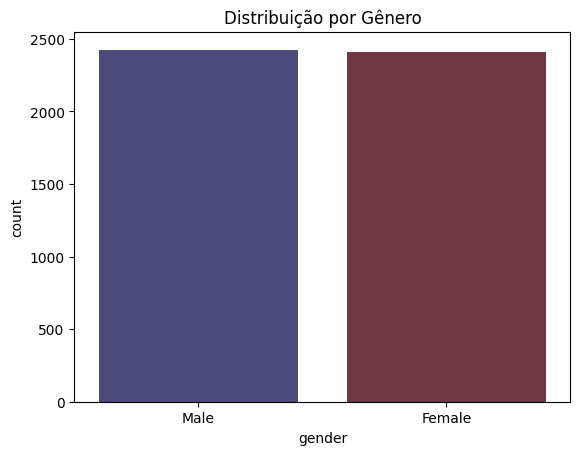

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1396\1555109043.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SeniorCitizen', data=df_merged, palette='icefire')


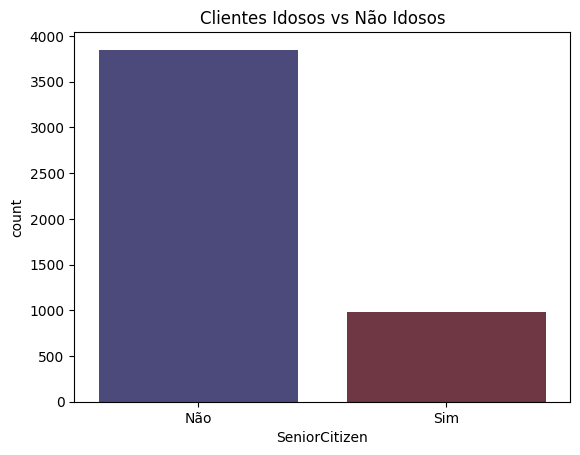

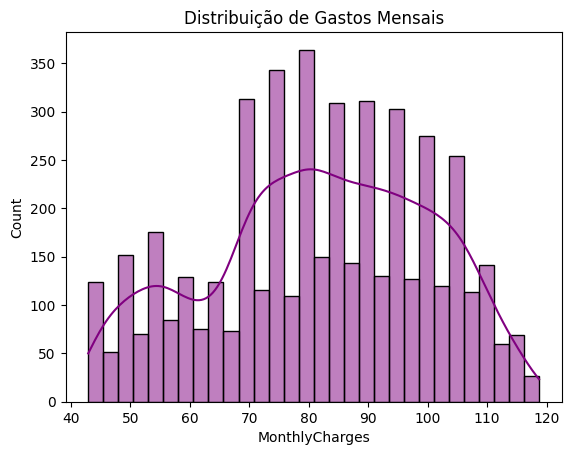

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1396\1555109043.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='InternetService', y='TotalCharges', data=df_merged, palette='icefire')


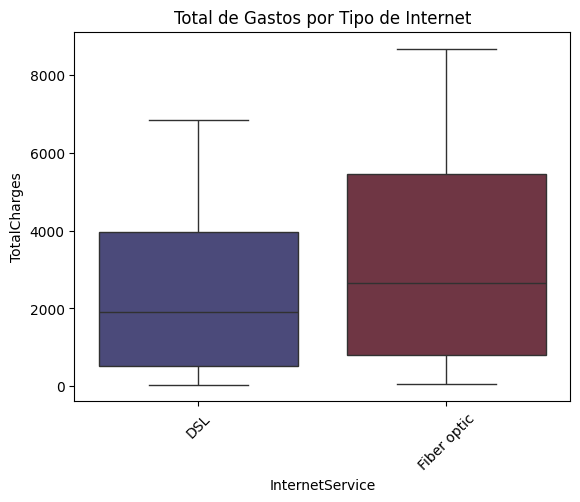

In [17]:
#Gênero dos clientes
sns.countplot(x='gender', data=df_merged, palette='icefire')
plt.title('Distribuição por Gênero')
plt.show()

#Idade (idoso ou não)
sns.countplot(x='SeniorCitizen', data=df_merged, palette='icefire')
plt.title('Clientes Idosos vs Não Idosos')
plt.xticks([0,1], ['Não', 'Sim'])
plt.show()

#Distribuição de gastos mensais
sns.histplot(df_merged['MonthlyCharges'], bins=30, kde=True, color='purple')
plt.title('Distribuição de Gastos Mensais')
plt.show()

#Total gasto vs tipo de serviço de internet
sns.boxplot(x='InternetService', y='TotalCharges', data=df_merged, palette='icefire')
plt.title('Total de Gastos por Tipo de Internet')
plt.xticks(rotation=45)
plt.show()

📊 1. Distribuição por Gênero:
A base de clientes está equilibrada entre homens e mulheres.
Isso indica que o gênero não é um fator discriminante no perfil de contratação de serviços.

👵 2. Clientes Idosos vs Não Idosos:
A maioria dos clientes não são idosos (cerca de 75%).
Apenas uma minoria (~25%) são clientes seniores.
Estratégias de marketing podem ser mais eficazes focando em adultos não idosos, ou criar ofertas personalizadas para o público sênior para aumentar sua adesão.

💸 3. Distribuição de Gastos Mensais:
A maioria dos clientes paga entre R$ 70 e R$ 100 por mês.
A curva mostra uma leve assimetria à direita, indicando alguns clientes com gastos bem acima da média (possivelmente com múltiplos serviços).
Existem picos de concentração em faixas de valor, sugerindo pacotes populares.

🌐 4. Total de Gastos por Tipo de Internet:
Clientes com Fiber optic têm gastos totais mais altos que os com DSL.
A mediana de gastos dos usuários de fibra é significativamente maior.
A fibra óptica pode estar associada a planos mais caros, maior tempo de contrato ou clientes com maior poder aquisitivo.
O maior intervalo de gastos sugere diversidade de planos ou adesão a múltiplos serviços.

🧠 Insights Gerais:
O perfil do cliente típico é um adulto não idoso, com gasto médio mensal entre R$ 70-100, e gasto total influenciado pelo tipo de internet.
O tipo de serviço (ex: fibra óptica) tem forte relação com o gasto total.
O gênero não impacta significativamente o comportamento de contratação ou gastos.
Clientes com fiber optic devem ser avaliados mais a fundo: são mais rentáveis, mas podem exigir maior suporte ou retenção.

In [19]:
#Desvolver um modelo
df_merged['HighSpender'] = (df_merged['MonthlyCharges'] > 90).astype(int)

In [20]:
#Selecionar variáveis preditoras e alvo
X = df_merged.drop(columns=['customerID', 'MonthlyCharges', 'HighSpender', 'TotalCharges'])  # Excluímos a variável que estamos prevendo
y = df_merged['HighSpender']

#Codificar variáveis categóricas
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

#Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Acurácia: {acc:.2f}")
print(f"Precisão: {prec:.2f}")
print(f"Recall: {rec:.2f}")

Acurácia: 0.95
Precisão: 0.95
Recall: 0.92


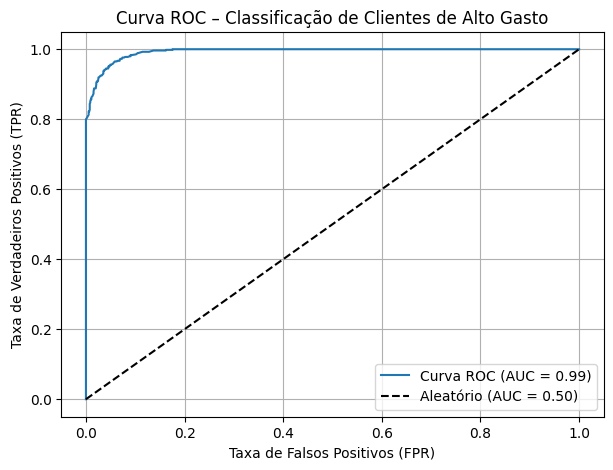

In [21]:
from sklearn.metrics import roc_curve, auc

#Obter as probabilidades para a classe positiva (1 = alto gasto)
y_proba = model.predict_proba(X_test)[:, 1]

#Calcular FPR (false positive rate) e TPR (true positive rate)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

#Calcular AUC
roc_auc = auc(fpr, tpr)

#Plotar curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC – Classificação de Clientes de Alto Gasto')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

O modelo tem altíssima capacidade de discriminação entre clientes com alto gasto (> R$ 90) e os demais.
A curva ROC se aproxima bastante do canto superior esquerdo (FPR ≈ 0, TPR ≈ 1), o que indica baixo número de falsos positivos e muitos verdadeiros positivos.
A AUC de 0.99 significa que, em 99% dos casos, o modelo consegue distinguir corretamente entre um cliente de alto e baixo gasto.

O modelo aprendeu muito bem os padrões de comportamento que levam a altos gastos mensais.
Ele pode ser usado com confiança para: Segmentação de clientes para planos premium
Campanhas específicas de fidelização
Análises financeiras e precificação

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.2f}")

print(y.value_counts(normalize=True))

Acurácia: 0.95
HighSpender
0    0.640331
1    0.359669
Name: proportion, dtype: float64


In [23]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_encoded, y)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Reavaliar métricas
from sklearn.metrics import accuracy_score, roc_auc_score

acc_best = accuracy_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Melhor Acurácia: {acc_best:.4f}")
print(f"AUC-ROC (com novo modelo): {auc_best:.4f}")

Melhor Acurácia: 0.9511
AUC-ROC (com novo modelo): 0.9934


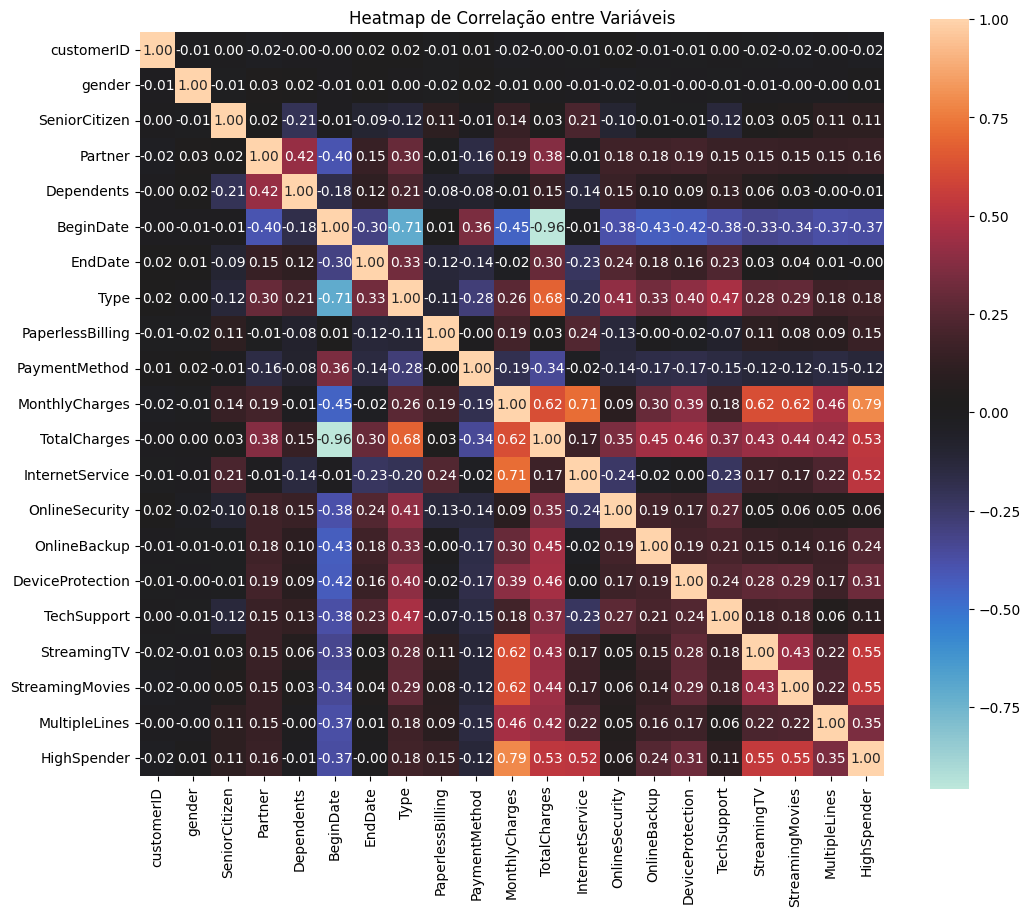

In [25]:
df_corr = df_merged.copy()

for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])
#Calcular matriz de correlação
corr_matrix = df_corr.corr()
#Plotar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='icefire', square=True)
plt.title("Heatmap de Correlação entre Variáveis")
plt.show()

**Interpretação Estratégica:**
Gastos elevados estão fortemente ligados à quantidade e tipo de serviço contratado, especialmente:

Internet de maior custo (InternetService)

Serviços de entretenimento (StreamingTV, StreamingMovies)

Adicionais como MultipleLines e DeviceProtection

Clientes com esses serviços contratados são os melhores alvos para:

Ofertas de fidelização

Campanhas de upsell

Planos personalizados

**Recomendação Técnica:**
Você pode melhorar ainda mais a acurácia e interpretabilidade do modelo ao:

Selecionar somente as variáveis mais correlacionadas (feature selection)

Remover variáveis redundantes ou irrelevantes (como gender, Partner, etc.)

# Relatório

**Insights Estratégicos:**

Os clientes com serviços digitais premium e múltiplas linhas são os que mais tendem a gastar acima da média.
Variáveis relacionadas ao perfil pessoal (ex: gênero, parceiro, dependentes) tiveram baixa influência no comportamento de gasto.
O modelo é útil para segmentar clientes de alto valor para:

Estratégias de retenção

Ofertas personalizadas

Campanhas de marketing direcionadas

# Conclusão

Foco em serviços correlacionados a maior receita, como internet de qualidade, streaming e múltiplas linhas.
Desconsiderar variáveis irrelevantes nas próximas versões do modelo para otimização de performance.
Avaliar implantação do modelo em ambiente produtivo para classificar novos clientes automaticamente.

# **Nathália Sorg**